# Single-Device Training

## The Fundamentals Before Parallelism

**Scenario**: A genomics lab trains a drug response classifier on gene expression data. Before scaling to multiple GPUs with Data Parallelism or FSDP, we need to understand the **single-device training loop** — the foundation everything else builds on.

This notebook covers:

1. **Data** — synthetic gene expression features + drug response labels
2. **Model** — a simple classifier with Flax `nn.Module`
3. **Loss & metrics** — cross-entropy loss, accuracy tracking
4. **Training state** — bundling params, optimizer, and apply function
5. **Training step** — forward → backward → update in one `jit`-compiled function
6. **Training loop** — iterating steps and monitoring convergence
7. **Gradient accumulation** — processing large batches in smaller chunks

Based on the [UvA DLC FSDP tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/scaling/JAX/data_parallel_fsdp.html) — this is the single-device baseline that the DP and FSDP notebooks build upon.

---

## 1 — Setup

In [2]:
import warnings
from typing import Any, Callable, Tuple

import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import optax
from flax.training import train_state
from jax import random

warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams["font.family"] = "DejaVu Sans"

PyTree = Any
Metrics = dict[str, Tuple[jax.Array, jax.Array]]  # (sum, count)

print(f"JAX version: {jax.__version__}")
print(f"Devices: {jax.devices()}")

JAX version: 0.9.1
Devices: [CpuDevice(id=0)]


---

## 2 — Dataset

We generate synthetic gene expression profiles (784 genes) with 5 drug response classes. This is the same data used in the DP and FSDP notebooks, so we can compare results.

In [3]:
N_CLASSES = 5
INPUT_SIZE = 784
BATCH_SIZE = 512
HIDDEN_SIZE = 1024

# Generate synthetic gene expression data
data_rng = random.PRNGKey(42)
rng_x, rng_y = random.split(data_rng)
inputs = random.normal(rng_x, (BATCH_SIZE, INPUT_SIZE))
labels = random.randint(rng_y, (BATCH_SIZE,), 0, N_CLASSES)

print(f"Inputs:  {inputs.shape}  (512 samples × 784 genes)")
print(f"Labels:  {labels.shape}  ({N_CLASSES} drug response categories)")
print(f"Class distribution: {dict(zip(*np.unique(np.array(labels), return_counts=True)))}")

W0314 08:06:20.433020 24479278 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Inputs:  (512, 784)  (512 samples × 784 genes)
Labels:  (512,)  (5 drug response categories)
Class distribution: {np.int32(0): np.int64(109), np.int32(1): np.int64(100), np.int32(2): np.int64(99), np.int32(3): np.int64(114), np.int32(4): np.int64(90)}


---

## 3 — Model

A two-layer classifier:

$$x \xrightarrow{\text{Dense}(784 \to 1024)} \text{SiLU} \xrightarrow{\text{Dropout}} \xrightarrow{\text{Dense}(1024 \to 5)} \text{logits}$$

This is the same architecture used in the FSDP notebook's `DPClassifier` and `FSDPClassifier` — just without any parallelism wrappers.

In [4]:
class Classifier(nn.Module):
    """Simple drug response classifier."""
    hidden_size: int = HIDDEN_SIZE
    num_classes: int = N_CLASSES
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, x: jax.Array, train: bool) -> jax.Array:
        x = nn.Dense(features=self.hidden_size, name="input_dense")(x)
        x = nn.silu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not train)(x)
        x = nn.Dense(features=self.num_classes, name="output_dense")(x)
        return x

### How `nn.compact` works

With `@nn.compact`, Flax creates parameters **on the first call**. The `Dense` layers declare their weights lazily — no need for a separate `setup` method:

```python
# nn.Dense(features=1024) creates:
#   kernel: (784, 1024)  — weight matrix
#   bias:   (1024,)      — bias vector
```

The `train` flag controls dropout: active during training (randomly zeros neurons), disabled during evaluation.

In [5]:
# Initialize the model to inspect parameters
model = Classifier()
init_rng = random.PRNGKey(0)
variables = model.init({"params": init_rng}, inputs[:1], train=False)

print("Parameter shapes:")
for name, param in jax.tree_util.tree_leaves_with_path(variables["params"]):
    path = "/".join(str(k.key) for k in name)
    print(f"  {path:<30} {param.shape}")

total_params = sum(p.size for p in jax.tree_util.tree_leaves(variables["params"]))
print(f"\nTotal parameters: {total_params:,}")
print(f"Memory (float32): {total_params * 4 / 1024:.1f} KB")

Parameter shapes:
  input_dense/bias               (1024,)
  input_dense/kernel             (784, 1024)
  output_dense/bias              (5,)
  output_dense/kernel            (1024, 5)

Total parameters: 808,965
Memory (float32): 3160.0 KB


---

## 4 — Loss Function & Metrics

The loss function computes softmax cross-entropy and tracks accuracy. It returns both the scalar loss (for `jax.grad`) and metrics (for logging).

**Why return `(sum, count)` instead of the mean?** When we later move to multiple devices, each device processes a different batch shard. Summing partial results and dividing at the end gives the correct global mean — averaging averages would not.

In [6]:
def loss_fn(
    params: PyTree, apply_fn: Callable, x: jax.Array,
    labels: jax.Array, rng: jax.Array,
) -> Tuple[jax.Array, Metrics]:
    """Compute cross-entropy loss and accuracy metrics."""
    logits = apply_fn({"params": params}, x, train=True, rngs={"dropout": rng})

    # Cross-entropy loss
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()

    # Accuracy tracking
    correct = (logits.argmax(axis=-1) == labels).sum()
    total = jnp.array(labels.shape[0], dtype=jnp.float32)

    metrics = {
        "loss": (loss * total, total),        # (sum_of_losses, count)
        "accuracy": (correct, total),          # (num_correct, count)
    }
    return loss, metrics

### Anatomy of `jax.grad` with `has_aux=True`

`jax.grad(loss_fn, has_aux=True)` differentiates **only the first return value** (the loss scalar). The second return value (metrics) is passed through unchanged:

```python
grad_fn = jax.grad(loss_fn, has_aux=True)
grads, metrics = grad_fn(params, ...)  # grads has same structure as params
```

The `grads` pytree mirrors `params` — each leaf is `∂loss/∂param`.

In [7]:
# Test the loss function and its gradient
test_rng = random.PRNGKey(1)
loss_val, metrics = loss_fn(variables["params"], model.apply, inputs, labels, test_rng)
print(f"Loss: {loss_val:.4f}")
print(f"Accuracy: {float(metrics['accuracy'][0] / metrics['accuracy'][1]):.4f}")

# Compute gradients
grad_fn = jax.grad(loss_fn, has_aux=True)
grads, _ = grad_fn(variables["params"], model.apply, inputs, labels, test_rng)

print("\nGradient shapes (same as params):")
for name, g in jax.tree_util.tree_leaves_with_path(grads):
    path = "/".join(str(k.key) for k in name)
    print(f"  ∇{path:<28} {g.shape}  mean={float(g.mean()):.6f}")

Loss: 1.7591
Accuracy: 0.1934

Gradient shapes (same as params):
  ∇input_dense/bias             (1024,)  mean=0.000149
  ∇input_dense/kernel           (784, 1024)  mean=-0.000000
  ∇output_dense/bias            (5,)  mean=0.000000
  ∇output_dense/kernel          (1024, 5)  mean=0.000000


---

## 5 — Training State

Flax's `TrainState` bundles everything needed for training into a single object:

| Field | What it holds |
|-------|---------------|
| `params` | Model parameters (pytree of arrays) |
| `apply_fn` | The model's forward function |
| `tx` | The optimizer (e.g., AdamW) |
| `opt_state` | Optimizer state (momentum, variance estimates) |
| `step` | Training step counter |

We extend it with an `rng` field to manage dropout randomness.

In [8]:
class TrainState(train_state.TrainState):
    """TrainState with RNG for dropout."""
    rng: jax.Array


# Create the training state
model = Classifier()
optimizer = optax.adamw(learning_rate=1e-3)

model_init_rng = random.PRNGKey(0)
init_rng, rng = random.split(model_init_rng)
variables = model.init({"params": init_rng}, inputs, train=False)

state = TrainState.create(
    apply_fn=model.apply,
    params=variables["params"],
    tx=optimizer,
    rng=rng,
)

print(f"TrainState created:")
print(f"  step:      {state.step}")
print(f"  params:    {sum(p.size for p in jax.tree_util.tree_leaves(state.params)):,} parameters")
print(f"  optimizer: AdamW (lr=1e-3)")
print(f"  rng:       {state.rng}")

TrainState created:
  step:      0
  params:    808,965 parameters
  optimizer: AdamW (lr=1e-3)
  rng:       [ 928981903 3453687069]


### What `TrainState.create` does

1. Stores `apply_fn` and `params`
2. Initializes the optimizer state by calling `tx.init(params)` — for AdamW, this creates zero-initialized first and second moment estimates (same shape as params)
3. Sets `step = 0`

The `apply_gradients` method (used later) does:
```python
updates, new_opt_state = tx.update(grads, opt_state, params)
new_params = optax.apply_updates(params, updates)
```

---

## 6 — Training Step

A single training step has three stages:

```
1. Forward:   logits = model(params, x)           → compute predictions
2. Backward:  grads = ∂loss/∂params               → compute gradients via backprop
3. Update:    params ← adam(params, grads)         → adjust parameters
```

`jax.grad` handles stages 1 and 2 together — it traces the forward pass and computes gradients automatically.

In [9]:
@jax.jit
def train_step(
    state: TrainState, x: jax.Array, labels: jax.Array,
) -> Tuple[TrainState, Metrics]:
    """One training step: forward → backward → update."""
    # Split RNG: one for this step's dropout, one for future steps
    rng, step_rng = random.split(state.rng)

    # Forward + backward (jax.grad computes both)
    grads, metrics = jax.grad(loss_fn, has_aux=True)(
        state.params, state.apply_fn, x, labels, step_rng
    )

    # Update parameters using the optimizer
    new_state = state.apply_gradients(grads=grads, rng=rng)

    return new_state, metrics

### Why `@jax.jit`?

Without `jit`, JAX executes operations one at a time (eager mode). With `jit`, JAX:
1. **Traces** the function once to build a computation graph
2. **Compiles** it with XLA into optimized machine code
3. **Caches** the compiled version for subsequent calls

The first call is slower (compilation), but every subsequent call runs at full speed.

In [10]:
# Compile and test one step
state, metrics = train_step(state, inputs, labels)

loss_val = float(metrics["loss"][0] / metrics["loss"][1])
acc_val = float(metrics["accuracy"][0] / metrics["accuracy"][1])
print(f"After 1 step — loss: {loss_val:.4f}, accuracy: {acc_val:.4f}")

After 1 step — loss: 1.7630, accuracy: 0.1738


---

## 7 — Training Loop

Now we run multiple training steps and track metrics over time.

In [11]:
# Re-initialize for a clean run
model = Classifier()
optimizer = optax.adamw(learning_rate=1e-3)

model_init_rng = random.PRNGKey(0)
init_rng, rng = random.split(model_init_rng)
variables = model.init({"params": init_rng}, inputs, train=False)

state = TrainState.create(
    apply_fn=model.apply,
    params=variables["params"],
    tx=optimizer,
    rng=rng,
)

# Training loop
NUM_STEPS = 100
history = {"loss": [], "accuracy": []}

for step in range(NUM_STEPS):
    state, metrics = train_step(state, inputs, labels)

    loss_val = float(metrics["loss"][0] / metrics["loss"][1])
    acc_val = float(metrics["accuracy"][0] / metrics["accuracy"][1])
    history["loss"].append(loss_val)
    history["accuracy"].append(acc_val)

    if step % 20 == 0 or step == NUM_STEPS - 1:
        print(f"Step {step:3d} — loss: {loss_val:.4f}, accuracy: {acc_val:.2%}")

Step   0 — loss: 1.7630, accuracy: 17.38%
Step  20 — loss: 0.0027, accuracy: 100.00%
Step  40 — loss: 0.0004, accuracy: 100.00%
Step  60 — loss: 0.0003, accuracy: 100.00%
Step  80 — loss: 0.0003, accuracy: 100.00%
Step  99 — loss: 0.0002, accuracy: 100.00%


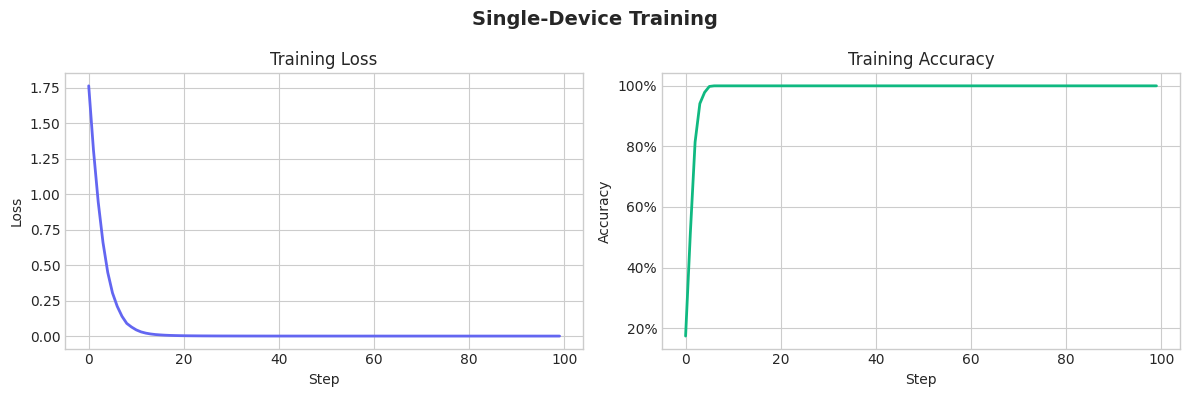

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["loss"], color="#6366f1", linewidth=2)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")

axes[1].plot(history["accuracy"], color="#10b981", linewidth=2)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training Accuracy")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

fig.suptitle("Single-Device Training", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

## 8 — Evaluation

During evaluation, we disable dropout (`train=False`) and don't compute gradients.

In [13]:
@jax.jit
def eval_step(state: TrainState, x: jax.Array, labels: jax.Array) -> Metrics:
    """Evaluate without dropout or gradient computation."""
    logits = state.apply_fn({"params": state.params}, x, train=False)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()
    correct = (logits.argmax(axis=-1) == labels).sum()
    total = jnp.array(labels.shape[0], dtype=jnp.float32)
    return {"loss": (loss * total, total), "accuracy": (correct, total)}


eval_metrics = eval_step(state, inputs, labels)
eval_loss = float(eval_metrics["loss"][0] / eval_metrics["loss"][1])
eval_acc = float(eval_metrics["accuracy"][0] / eval_metrics["accuracy"][1])
print(f"Eval — loss: {eval_loss:.4f}, accuracy: {eval_acc:.2%}")

Eval — loss: 0.0002, accuracy: 100.00%


---

## 9 — Gradient Accumulation

When a batch is **too large to fit in GPU memory**, we can split it into smaller **minibatches**, compute gradients on each, and **average** the results. This gives the same gradients as processing the full batch at once.

```
Full batch (512 samples):
  ┌─────────────────────────────────────────────┐
  │              512 samples                     │  → one big grad computation
  └─────────────────────────────────────────────┘

With gradient accumulation (4 minibatches of 128):
  ┌───────────┐ ┌───────────┐ ┌───────────┐ ┌───────────┐
  │  128 (0)  │ │  128 (1)  │ │  128 (2)  │ │  128 (3)  │
  └─────┬─────┘ └─────┬─────┘ └─────┬─────┘ └─────┬─────┘
        ∇₀             ∇₁             ∇₂             ∇₃
         \              \             /              /
          ───────── average ─────────
                      ∇
```

This is essential for training on limited hardware — and it's a **prerequisite concept** for data parallelism, where different devices process different minibatches simultaneously.

In [14]:
def accumulate_gradients(
    state: TrainState, x: jax.Array, labels: jax.Array,
    rng: jax.Array, num_minibatches: int,
) -> Tuple[PyTree, Metrics]:
    """Accumulate gradients over minibatches using lax.scan."""
    batch_size = x.shape[0]
    minibatch_size = batch_size // num_minibatches
    rngs = random.split(rng, num_minibatches)

    def _minibatch_step(carry, minibatch_idx):
        grad_acc, metric_acc = carry

        # Slice out this minibatch
        start = minibatch_idx * minibatch_size
        mb_x = jax.lax.dynamic_slice_in_dim(x, start, minibatch_size, axis=0)
        mb_labels = jax.lax.dynamic_slice_in_dim(labels, start, minibatch_size, axis=0)

        # Compute gradients on this minibatch
        grads, metrics = jax.grad(loss_fn, has_aux=True)(
            state.params, state.apply_fn, mb_x, mb_labels, rngs[minibatch_idx]
        )

        # Accumulate (sum)
        grad_acc = jax.tree.map(jnp.add, grad_acc, grads)
        metric_acc = jax.tree.map(jnp.add, metric_acc, metrics)
        return (grad_acc, metric_acc), None

    # Initialize accumulators with zeros
    init_grads = jax.tree.map(jnp.zeros_like, state.params)
    init_metrics = {
        "loss": (jnp.zeros(()), jnp.zeros(())),
        "accuracy": (jnp.zeros(()), jnp.zeros(())),
    }

    # Scan over minibatch indices
    (grads, metrics), _ = jax.lax.scan(
        _minibatch_step, (init_grads, init_metrics), jnp.arange(num_minibatches)
    )

    # Average gradients
    grads = jax.tree.map(lambda g: g / num_minibatches, grads)
    return grads, metrics

### Why `lax.scan` instead of a Python `for` loop?

A Python `for` loop would **unroll** at trace time — creating 4 copies of the gradient computation in the XLA graph. `lax.scan` compiles to a **single loop** in XLA, keeping the compiled code small regardless of `num_minibatches`.

```python
# Python loop: unrolls to 4× the graph size
for i in range(4):
    grads += compute_grad(batch[i])

# lax.scan: compiles to a single loop body
grads, _ = lax.scan(compute_grad_step, init, jnp.arange(4))
```

In [15]:
NUM_MINIBATCHES = 4


@jax.jit
def train_step_accum(
    state: TrainState, x: jax.Array, labels: jax.Array,
) -> Tuple[TrainState, Metrics]:
    """Training step with gradient accumulation."""
    rng, step_rng = random.split(state.rng)

    grads, metrics = accumulate_gradients(
        state, x, labels, step_rng, num_minibatches=NUM_MINIBATCHES
    )

    new_state = state.apply_gradients(grads=grads, rng=rng)
    return new_state, metrics

In [16]:
# Re-initialize and train with gradient accumulation
model = Classifier()
optimizer = optax.adamw(learning_rate=1e-3)

model_init_rng = random.PRNGKey(0)
init_rng, rng = random.split(model_init_rng)
variables = model.init({"params": init_rng}, inputs, train=False)

state_accum = TrainState.create(
    apply_fn=model.apply,
    params=variables["params"],
    tx=optimizer,
    rng=rng,
)

history_accum = {"loss": [], "accuracy": []}

for step in range(NUM_STEPS):
    state_accum, metrics = train_step_accum(state_accum, inputs, labels)

    loss_val = float(metrics["loss"][0] / metrics["loss"][1])
    acc_val = float(metrics["accuracy"][0] / metrics["accuracy"][1])
    history_accum["loss"].append(loss_val)
    history_accum["accuracy"].append(acc_val)

    if step % 20 == 0 or step == NUM_STEPS - 1:
        print(f"Step {step:3d} — loss: {loss_val:.4f}, accuracy: {acc_val:.2%}")

Step   0 — loss: 1.7596, accuracy: 21.48%
Step  20 — loss: 0.0029, accuracy: 100.00%
Step  40 — loss: 0.0004, accuracy: 100.00%
Step  60 — loss: 0.0003, accuracy: 100.00%
Step  80 — loss: 0.0003, accuracy: 100.00%
Step  99 — loss: 0.0002, accuracy: 100.00%


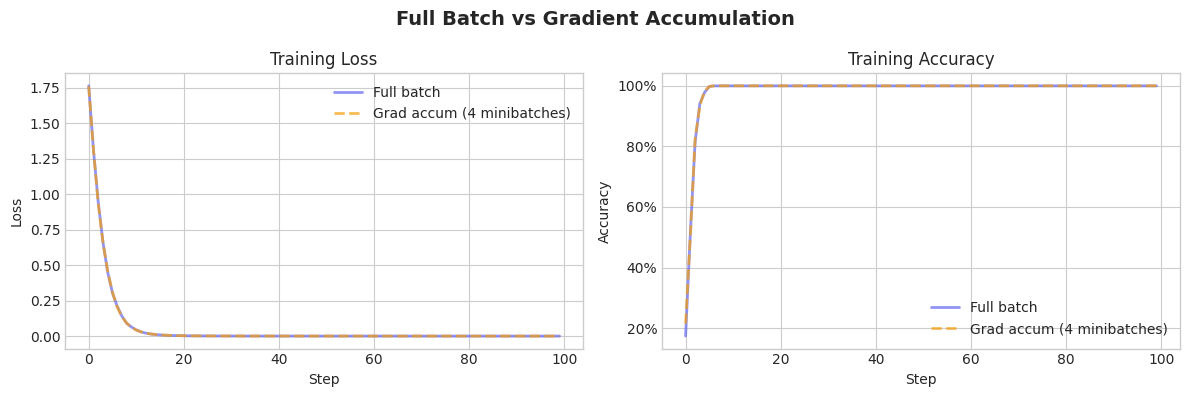

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["loss"], color="#6366f1", linewidth=2, alpha=0.7, label="Full batch")
axes[0].plot(history_accum["loss"], color="#f59e0b", linewidth=2, alpha=0.7,
             linestyle="--", label=f"Grad accum ({NUM_MINIBATCHES} minibatches)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()

axes[1].plot(history["accuracy"], color="#6366f1", linewidth=2, alpha=0.7, label="Full batch")
axes[1].plot(history_accum["accuracy"], color="#f59e0b", linewidth=2, alpha=0.7,
             linestyle="--", label=f"Grad accum ({NUM_MINIBATCHES} minibatches)")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training Accuracy")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
axes[1].legend()

fig.suptitle("Full Batch vs Gradient Accumulation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

The curves differ slightly because **dropout uses different RNG splits** — with gradient accumulation, each minibatch gets its own dropout mask, while the full-batch version applies a single mask. The overall convergence behavior is the same.

---

## 10 — What Changes with Parallelism?

This single-device loop is the foundation. Here's what each parallelism strategy adds:

| | Single Device | Data Parallel (DP) | FSDP |
|---|---|---|---|
| **Params** | One copy | Replicated on N devices | Sharded across N devices |
| **Data** | Full batch on one device | Batch split across devices | Batch split across devices |
| **Forward** | `model(params, x)` | Same, but each device gets `x/N` | `all_gather` params → compute → free |
| **Backward** | `jax.grad(loss_fn)` | Same per device | Custom grad: `psum_scatter` |
| **Gradient sync** | None needed | `pmean` across all devices | `pmean` for replicated params only |
| **Update** | `apply_gradients` | Same (identical on all devices) | Same (each device updates its shard) |
| **Memory/device** | $O(P)$ | $O(P)$ — no savings | $O(P/N)$ — N× savings |
| **Speed** | Baseline | ~N× faster (more data/step) | ~N× faster, less memory |

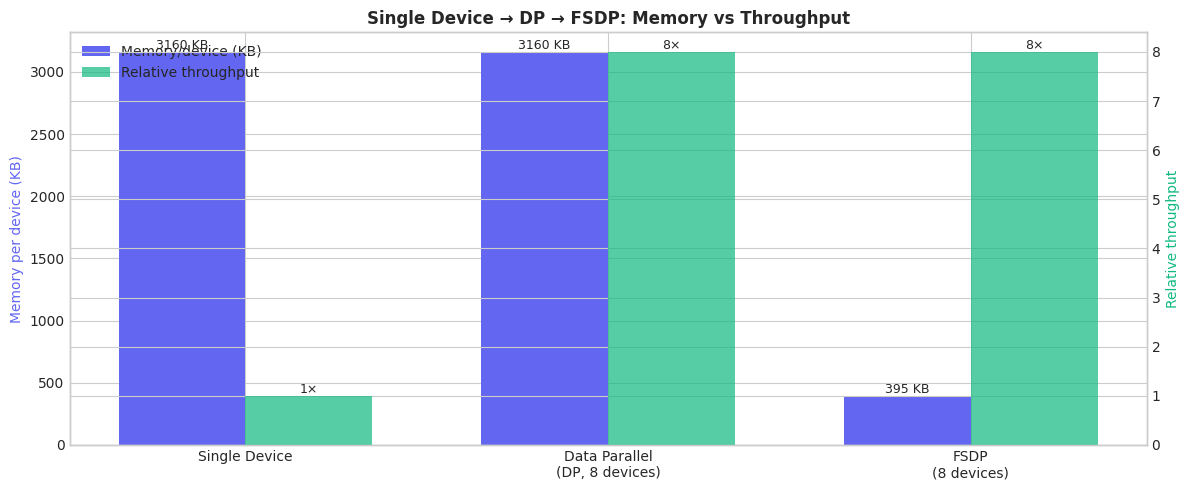

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

strategies = ["Single Device", "Data Parallel\n(DP, 8 devices)", "FSDP\n(8 devices)"]
n_devices = [1, 8, 8]

total_params = sum(p.size for p in jax.tree_util.tree_leaves(state.params))
param_memory_kb = total_params * 4 / 1024  # float32

# Memory per device
memories = [
    param_memory_kb,          # single device: full model
    param_memory_kb,          # DP: full model replicated
    param_memory_kb / 8,      # FSDP: sharded
]

# Throughput (relative)
throughputs = [1, 8, 8]  # simplification — FSDP has communication overhead

x_pos = np.arange(len(strategies))
width = 0.35

bars1 = ax.bar(x_pos - width/2, memories, width, color="#6366f1", label="Memory/device (KB)")
ax.bar_label(bars1, fmt="%.0f KB", fontsize=9)

ax2 = ax.twinx()
bars2 = ax2.bar(x_pos + width/2, throughputs, width, color="#10b981", alpha=0.7,
                label="Relative throughput")
ax2.bar_label(bars2, fmt="%.0f×", fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(strategies)
ax.set_ylabel("Memory per device (KB)", color="#6366f1")
ax2.set_ylabel("Relative throughput", color="#10b981")
ax.set_title("Single Device → DP → FSDP: Memory vs Throughput", fontweight="bold")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

---

## Summary

The single-device training loop has five components:

| Component | Purpose |
|-----------|--------|
| **Model** | `nn.Module` defining the forward pass |
| **Loss function** | Scalar loss + metrics, compatible with `jax.grad` |
| **TrainState** | Bundles params, optimizer, and apply function |
| **Training step** | `jit`-compiled: grad → update |
| **Gradient accumulation** | Process large batches in smaller chunks via `lax.scan` |

When moving to **Data Parallelism**, the only changes are:
1. Shard the batch across devices
2. Add `pmean` to sync gradients after backward

When moving to **FSDP**, additionally:
3. Shard parameters across devices
4. `all_gather` before each layer, `psum_scatter` in backward

See [2-2-1-data_parallel_fsdp](./2-2-1-data_parallel_fsdp.ipynb) and [2-2-2-fsdp_step_by_step](./2-2-2-fsdp_step_by_step.ipynb) for these extensions.